In [1]:
import os
from dotenv import load_dotenv
from pathlib import Path
import pandas as pd
import numpy as np
import requests
import rasterio
from rasterio.merge import merge
from rasterio.mask import mask
import geopandas as gpd
from shapely.geometry import box
import matplotlib.pyplot as plt
from tqdm import tqdm

# Load environment variables
load_dotenv()

# Get data directory
DATA_DIR = Path(os.getenv('DATA_DIR')) / 'sumatra-deforestaion'
RAW_DATA = DATA_DIR / 'raw'
PROCESSED_DATA = DATA_DIR / 'processed'
HANSEN_TILES = RAW_DATA / 'hansen_tiles'

# Create directories
RAW_DATA.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA.mkdir(parents=True, exist_ok=True)
HANSEN_TILES.mkdir(parents=True, exist_ok=True)


# Define Study Area
Sumatra coordinates: approximately -6° to 6° N, 95° to 106° E


In [2]:
# Download Indonesia boundaries
url = "https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_IDN_1.json"
indonesia_adm1 = gpd.read_file(url)

# Filter for Sumatra provinces only
sumatra_provinces_list = [
    'Aceh', 'SumateraUtara', 'SumateraBarat', 'Riau', 
    'Jambi', 'SumateraSelatan', 'Bengkulu', 'Lampung',
    'BangkaBelitung', 'KepulauanRiau'
]

sumatra_gdf = indonesia_adm1[indonesia_adm1['NAME_1'].isin(sumatra_provinces_list)]
sumatra_bounds = sumatra_gdf.total_bounds  # (minx, miny, maxx, maxy)

print(f"Sumatra actual bounds: {sumatra_bounds}")

# Save for later use
sumatra_gdf.to_file(RAW_DATA / 'sumatra_boundary.geojson', driver='GeoJSON')

Sumatra actual bounds: [ 95.0097  -6.1686 109.1638   6.0761]


In [3]:

sumatra_bbox = {
    'min_lon': 95.0097,
    'max_lon': 109.1638,
    'min_lat': -6.1686,
    'max_lat': 6.0761
}

print(f"Sumatra bounding box:")
print(f"  Longitude: {sumatra_bbox['min_lon']}° to {sumatra_bbox['max_lon']}°")
print(f"  Latitude: {sumatra_bbox['min_lat']}° to {sumatra_bbox['max_lat']}°")


Sumatra bounding box:
  Longitude: 95.0097° to 109.1638°
  Latitude: -6.1686° to 6.0761°


# Get the Deforestation Data

## Identify Required Hansen Tiles

In [4]:
def get_hansen_tile_name(lat, lon):
    """
    Convert lat/lon to Hansen tile naming convention
    Hansen tiles are 10x10 degrees
    Example: 00N_100E means 0-10°N, 100-110°E
    """
    # Determine latitude band
    if lat >= 0:
        lat_band = f"{int(lat // 10) * 10:02d}N"
    else:
        lat_band = f"{int(abs(lat) // 10) * 10:02d}S"
    
    # Determine longitude band
    if lon >= 0:
        lon_band = f"{int(lon // 10) * 10:03d}E"
    else:
        lon_band = f"{int(abs(lon) // 10) * 10:03d}W"
    
    return f"{lat_band}_{lon_band}"

# Get all tiles needed for Sumatra
tiles_needed = set()

# Sample points across the bounding box to find all tiles
for lat in range(int(sumatra_bbox['min_lat']), int(sumatra_bbox['max_lat']) + 1, 1):
    for lon in range(int(sumatra_bbox['min_lon']), int(sumatra_bbox['max_lon']) + 1, 1):
        tile = get_hansen_tile_name(lat, lon)
        tiles_needed.add(tile)

tiles_needed = sorted(list(tiles_needed))
print(f"\nHansen tiles needed for Sumatra: {len(tiles_needed)}")
for tile in tiles_needed:
    print(f"  - {tile}")


Hansen tiles needed for Sumatra: 4
  - 00N_090E
  - 00N_100E
  - 00S_090E
  - 00S_100E


## Download Hansen Tiles

In [4]:
def download_hansen_tile(tile_name, data_type='lossyear', version='GFC-2024-v1.12'):
    """
    Download a Hansen tile from Google Cloud Storage
    Returns None if tile doesn't exist (e.g., ocean tiles)
    """
    base_url = f"https://storage.googleapis.com/earthenginepartners-hansen/{version}"
    filename = f"Hansen_{version}_{data_type}_{tile_name}.tif"
    url = f"{base_url}/{filename}"
    output_path = HANSEN_TILES / filename
    
    # Skip if already downloaded
    if output_path.exists():
        print(f"  ✓ {filename} already exists")
        return output_path
    
    print(f"  Downloading {filename}...")
    try:
        response = requests.get(url, stream=True, timeout=300)
        response.raise_for_status()
        
        total_size = int(response.headers.get('content-length', 0))
        
        with open(output_path, 'wb') as f:
            with tqdm(total=total_size, unit='B', unit_scale=True, desc=filename) as pbar:
                for chunk in response.iter_content(chunk_size=8192):
                    f.write(chunk)
                    pbar.update(len(chunk))
        
        print(f"  ✓ Downloaded {filename}")
        return output_path
    
    except requests.exceptions.HTTPError as e:
        if e.response.status_code == 404:
            print(f"  ⊗ Tile doesn't exist (likely ocean): {filename}")
            return None
        else:
            print(f"  ✗ HTTP Error downloading {filename}: {e}")
            return None
    except Exception as e:
        print(f"  ✗ Error downloading {filename}: {e}")
        return None

# Download lossyear tiles (shows which year forest was lost)
print("\n=== Downloading Hansen lossyear tiles ===")
lossyear_files = []

for tile in tiles_needed:
    filepath = download_hansen_tile(tile, data_type='lossyear')
    if filepath:  # Only add if download succeeded
        lossyear_files.append(filepath)

print(f"\n✓ Downloaded {len(lossyear_files)} / {len(tiles_needed)} tiles")
print(f"  ({len(tiles_needed) - len(lossyear_files)} tiles don't exist - likely ocean)")


=== Downloading Hansen lossyear tiles ===
  ✓ Hansen_GFC-2024-v1.12_lossyear_00N_090E.tif already exists
  ✓ Hansen_GFC-2024-v1.12_lossyear_00N_100E.tif already exists
  ⊗ Tile doesn't exist (likely ocean): Hansen_GFC-2024-v1.12_lossyear_00S_090E.tif
  ⊗ Tile doesn't exist (likely ocean): Hansen_GFC-2024-v1.12_lossyear_00S_100E.tif

✓ Downloaded 2 / 4 tiles
  (2 tiles don't exist - likely ocean)


## Download Treecover 2000 Tiles

In [5]:
# Download treecover2000 tiles (baseline forest cover in year 2000)
print("\n=== Downloading Hansen treecover2000 tiles ===")
treecover_files = []

for tile in tiles_needed:
    filepath = download_hansen_tile(tile, data_type='treecover2000')
    if filepath:
        treecover_files.append(filepath)

print(f"\n✓ Downloaded {len(treecover_files)} / {len(tiles_needed)} tiles")


=== Downloading Hansen treecover2000 tiles ===
  ✓ Hansen_GFC-2024-v1.12_treecover2000_00N_090E.tif already exists
  ✓ Hansen_GFC-2024-v1.12_treecover2000_00N_100E.tif already exists
  ⊗ Tile doesn't exist (likely ocean): Hansen_GFC-2024-v1.12_treecover2000_00S_090E.tif
  ⊗ Tile doesn't exist (likely ocean): Hansen_GFC-2024-v1.12_treecover2000_00S_100E.tif

✓ Downloaded 2 / 4 tiles


## Mosaic Tiles and Clip to Sumatra

In [6]:
def mosaic_and_clip_tiles(tile_files, bbox_gdf, output_name):
    """
    Mosaic multiple tiles and clip to bounding box
    """
    print(f"\nMosaicking {len(tile_files)} tiles...")
    
    # Open all tiles
    src_files_to_mosaic = []
    for fp in tile_files:
        src = rasterio.open(fp)
        src_files_to_mosaic.append(src)
    
    # Mosaic
    mosaic, out_trans = merge(src_files_to_mosaic)
    
    # Get metadata from first file
    out_meta = src_files_to_mosaic[0].meta.copy()
    out_meta.update({
        "driver": "GTiff",
        "height": mosaic.shape[1],
        "width": mosaic.shape[2],
        "transform": out_trans,
        "compress": "lzw"
    })
    
    # Save mosaicked raster
    mosaic_path = PROCESSED_DATA / f"sumatra_{output_name}_mosaic.tif"
    with rasterio.open(mosaic_path, "w", **out_meta) as dest:
        dest.write(mosaic)
    
    print(f"✓ Mosaic saved: {str(mosaic_path).split('/')[-1]}")
    
    # Clip to Sumatra bbox
    with rasterio.open(mosaic_path) as src:
        # Reproject bbox to match raster CRS if needed
        bbox_reproj = bbox_gdf.to_crs(src.crs)
        
        # Clip
        out_image, out_transform = mask(src, bbox_reproj.geometry, crop=True)
        out_meta = src.meta.copy()
        out_meta.update({
            "height": out_image.shape[1],
            "width": out_image.shape[2],
            "transform": out_transform
        })
        
        # Save clipped raster
        clipped_path = PROCESSED_DATA / f"sumatra_{output_name}_clipped.tif"
        with rasterio.open(clipped_path, "w", **out_meta) as dest:
            dest.write(out_image)
        
        print(f"✓ Clipped raster saved: {str(clipped_path).split('/')[-1]}")
    
    # Close all source files
    for src in src_files_to_mosaic:
        src.close()
    
    return clipped_path

# Mosaic and clip lossyear
lossyear_sumatra = mosaic_and_clip_tiles(lossyear_files, bbox_gdf, "lossyear")

# Mosaic and clip treecover
treecover_sumatra = mosaic_and_clip_tiles(treecover_files, bbox_gdf, "treecover2000")


Mosaicking 2 tiles...
✓ Mosaic saved: sumatra_lossyear_mosaic.tif
✓ Clipped raster saved: sumatra_lossyear_clipped.tif

Mosaicking 2 tiles...
✓ Mosaic saved: sumatra_treecover2000_mosaic.tif
✓ Clipped raster saved: sumatra_treecover2000_clipped.tif


## Calculate Annual Deforestation Statistics

In [7]:
def calculate_annual_forest_loss(lossyear_raster_path):
    """
    Calculate hectares of forest lost per year from lossyear raster
    
    Hansen lossyear encoding:
    - 0 = no loss
    - 1 = loss in 2001
    - 2 = loss in 2002
    - ...
    - 24 = loss in 2024
    """
    with rasterio.open(lossyear_raster_path) as src:
        lossyear = src.read(1)
        
        # Get pixel resolution (in degrees)
        pixel_width = src.res[0]
        pixel_height = src.res[1]
        
        # Calculate area per pixel in hectares
        # At equator: 1 degree ≈ 111 km
        # Adjust for latitude (approximate for Sumatra near equator)
        lat_center = (src.bounds.bottom + src.bounds.top) / 2
        km_per_degree_lon = 111.32 * np.cos(np.radians(lat_center))
        km_per_degree_lat = 111.32
        
        pixel_area_km2 = (pixel_width * km_per_degree_lon) * (pixel_height * km_per_degree_lat)
        pixel_area_ha = pixel_area_km2 * 100  # Convert km² to hectares
        
        print(f"Pixel resolution: {pixel_width}° x {pixel_height}°")
        print(f"Approximate pixel area: {pixel_area_ha:.4f} hectares")
    
    # Calculate loss per year
    annual_loss = []
    
    for year_code in range(1, 25):  # 1-24 for years 2001-2024
        year = 2000 + year_code
        pixels_lost = np.sum(lossyear == year_code)
        hectares_lost = pixels_lost * pixel_area_ha
        
        annual_loss.append({
            'year': year,
            'pixels_lost': int(pixels_lost),
            'forest_loss_hectares': hectares_lost
        })
        
        print(f"  {year}: {hectares_lost:,.0f} ha lost ({pixels_lost:,} pixels)")
    
    return pd.DataFrame(annual_loss)

# Calculate statistics
print("\n=== Calculating Annual Forest Loss ===")
deforestation_df = calculate_annual_forest_loss(lossyear_sumatra)

# Save to CSV
deforestation_df.to_csv(RAW_DATA / 'hansen_deforestation_sumatra.csv', index=False)
print(f"\n✓ Saved: {'hansen_deforestation_sumatra.csv'}")


=== Calculating Annual Forest Loss ===
Pixel resolution: 0.00025° x 0.00025°
Approximate pixel area: 0.0773 hectares
  2001: 209,564 ha lost (2,709,480 pixels)
  2002: 190,321 ha lost (2,460,682 pixels)
  2003: 91,346 ha lost (1,181,022 pixels)
  2004: 329,631 ha lost (4,261,843 pixels)
  2005: 295,273 ha lost (3,817,623 pixels)
  2006: 412,024 ha lost (5,327,112 pixels)
  2007: 430,771 ha lost (5,569,499 pixels)
  2008: 474,450 ha lost (6,134,228 pixels)
  2009: 485,563 ha lost (6,277,902 pixels)
  2010: 325,386 ha lost (4,206,953 pixels)
  2011: 348,875 ha lost (4,510,646 pixels)
  2012: 748,972 ha lost (9,683,551 pixels)
  2013: 279,868 ha lost (3,618,453 pixels)
  2014: 402,679 ha lost (5,206,282 pixels)
  2015: 367,581 ha lost (4,752,499 pixels)
  2016: 639,171 ha lost (8,263,923 pixels)
  2017: 395,206 ha lost (5,109,665 pixels)
  2018: 344,142 ha lost (4,449,459 pixels)
  2019: 324,700 ha lost (4,198,084 pixels)
  2020: 315,856 ha lost (4,083,741 pixels)
  2021: 287,320 ha lost

In [8]:
# Display summary
print("\n=== Deforestation Summary ===")
print(f"Total forest loss (2001-2024): {deforestation_df['forest_loss_hectares'].sum():,.0f} hectares")
print(f"Average annual loss: {deforestation_df['forest_loss_hectares'].mean():,.0f} hectares")
print(f"\nWorst years:")
print(deforestation_df.nlargest(5, 'forest_loss_hectares')[['year', 'forest_loss_hectares']])

# Preview data
print("\nFirst 10 years:")
display(deforestation_df.head(10))


=== Deforestation Summary ===
Total forest loss (2001-2024): 8,822,479 hectares
Average annual loss: 367,603 hectares

Worst years:
    year  forest_loss_hectares
11  2012         748971.794865
15  2016         639171.027440
8   2009         485562.737154
7   2008         474450.308081
22  2023         440258.052040

First 10 years:


,year,pixels_lost,forest_loss_hectares
0,2001,2709480,209564.043061
1,2002,2460682,190320.824885
2,2003,1181022,91345.846902
3,2004,4261843,329631.165380
4,2005,3817623,295273.082202
5,2006,5327112,412024.125869
6,2007,5569499,430771.486878
7,2008,6134228,474450.308081
8,2009,6277902,485562.737154
9,2010,4206953,325385.712258


# Visualize the Deforestation Data

## Setup

In [9]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle
import numpy as np
from PIL import Image
import seaborn as sns

# Set style
sns.set_style("white")
plt.rcParams['figure.dpi'] = 150

## Load Raster Data

In [10]:
# Load the processed rasters
lossyear_raster = rasterio.open(lossyear_sumatra)
treecover_raster = rasterio.open(treecover_sumatra)

# Read data
lossyear_data = lossyear_raster.read(1)
treecover_data = treecover_raster.read(1)

print(f"Lossyear shape: {lossyear_data.shape}")
print(f"Treecover shape: {treecover_data.shape}")
print(f"Lossyear range: {lossyear_data.min()} to {lossyear_data.max()}")
print(f"Treecover range: {treecover_data.min()} to {treecover_data.max()}")

Lossyear shape: (24000, 44000)
Treecover shape: (24000, 44000)
Lossyear range: 0 to 24
Treecover range: 0 to 100


## Create Base Map - Forest Cover 2000

In [11]:
print(f"Raster dimensions: {treecover_data.shape}")
print(f"Total pixels: {treecover_data.size:,}")

Raster dimensions: (24000, 44000)
Total pixels: 1,056,000,000


1 billion pixels -> downsample!

In [13]:
from skimage.transform import resize

# Downsample to ~1000x2000 pixels (manageable size)
downsample_factor = 20
small_treecover = treecover_data[::downsample_factor, ::downsample_factor]
small_lossyear = lossyear_data[::downsample_factor, ::downsample_factor]

print(f"Downsampled dimensions: {small_treecover.shape}")
print(f"New pixel count: {small_treecover.size:,}")

# Save downsampled versions for all visualizations
np.save(PROCESSED_DATA / 'treecover_downsampled.npy', small_treecover)
np.save(PROCESSED_DATA / 'lossyear_downsampled.npy', small_lossyear)

print("✓ Saved downsampled arrays")

Downsampled dimensions: (1200, 2200)
New pixel count: 2,640,000
✓ Saved downsampled arrays


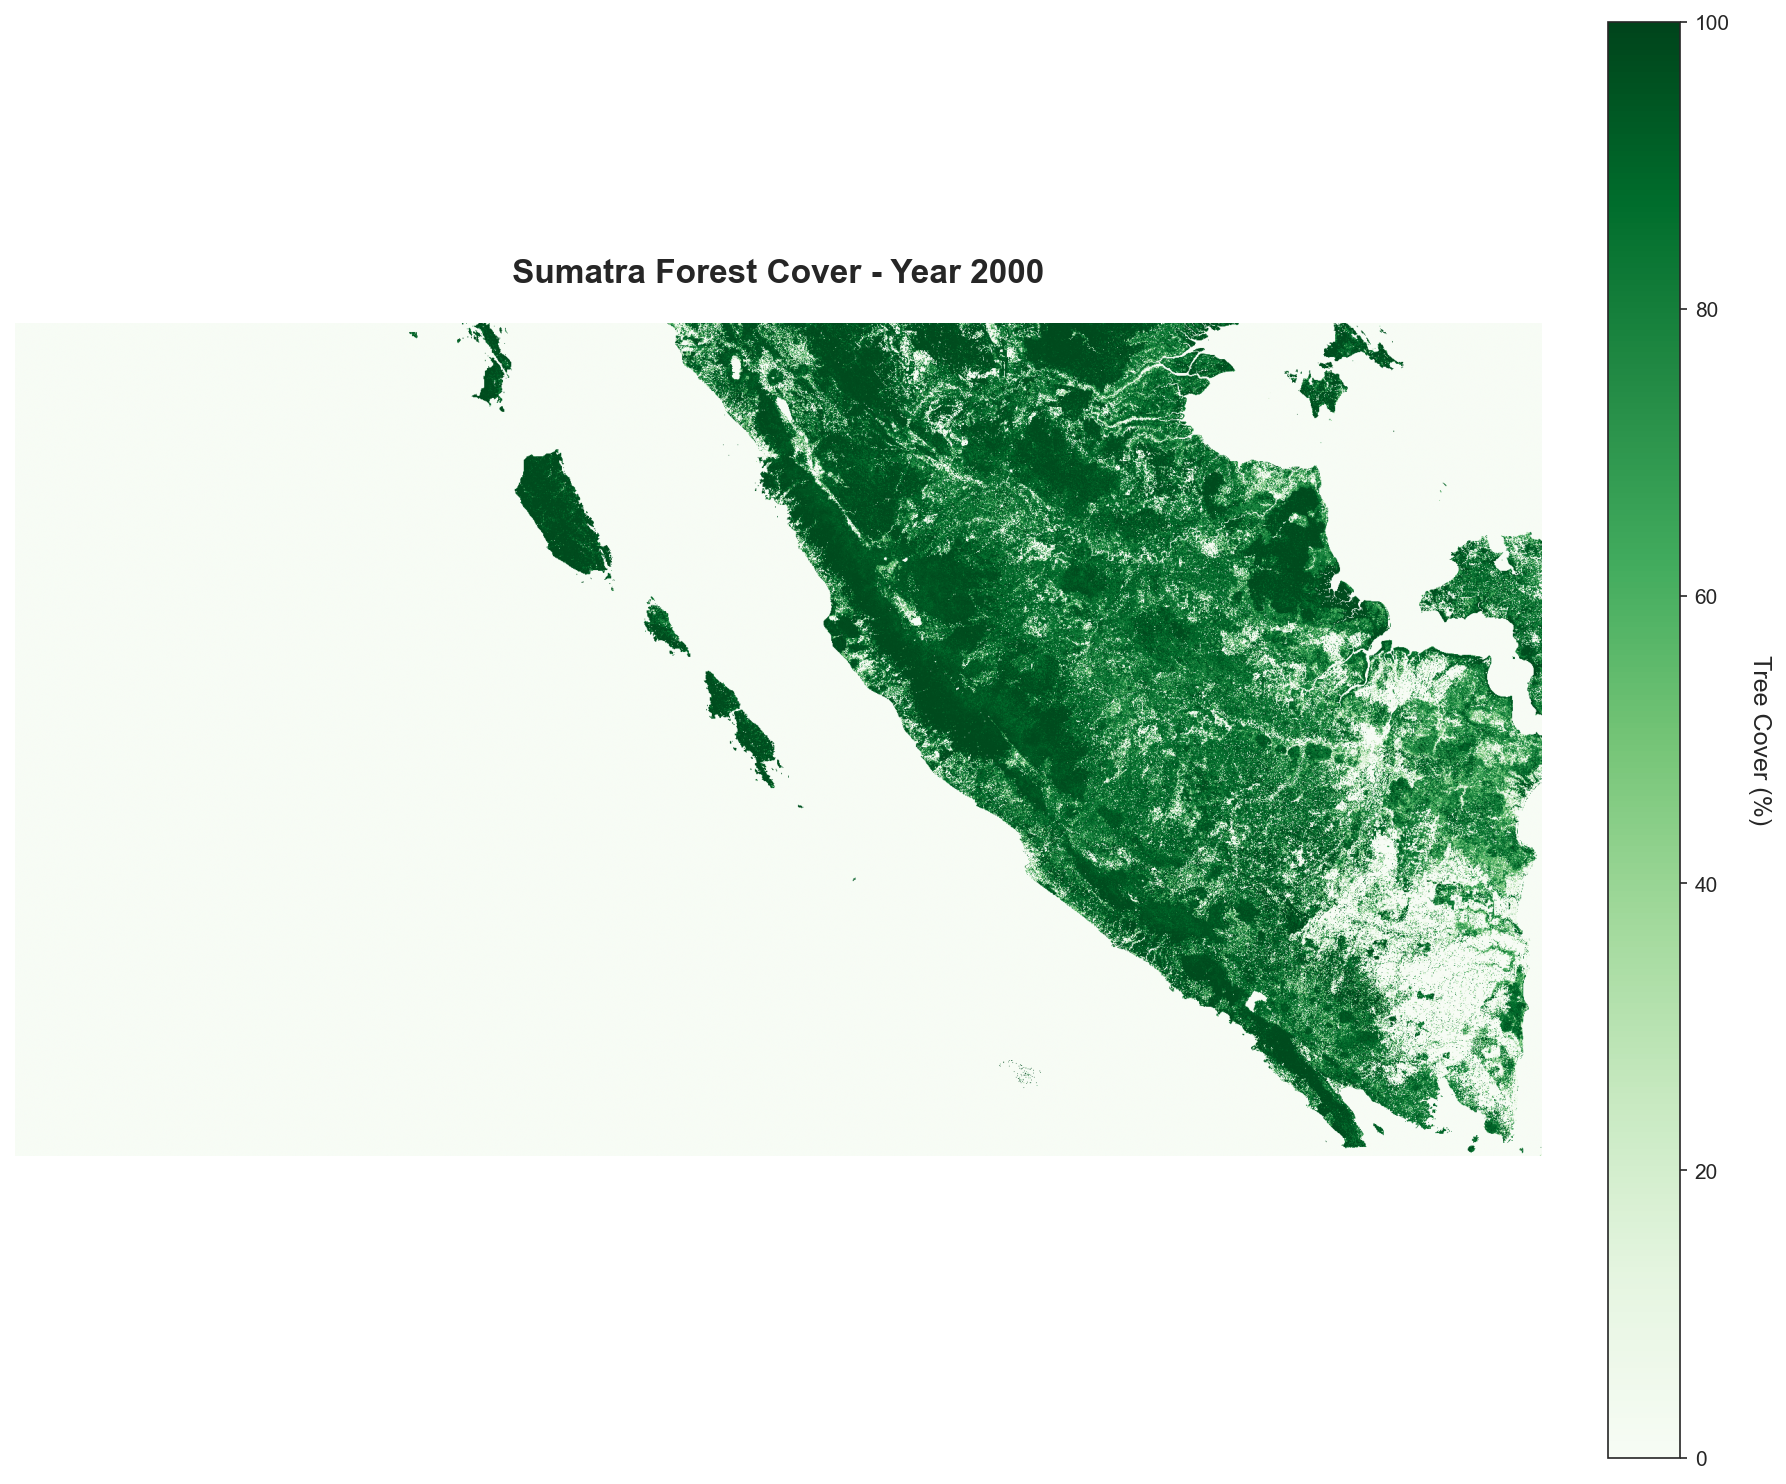

✓ Saved: 'sumatra_forest_2000.png'


In [16]:
fig, ax = plt.subplots(figsize=(12, 10))

# Create forest mask (areas with >30% tree cover)
forest_mask = small_treecover > 30

# Plot forest cover
im = ax.imshow(small_treecover, cmap='Greens', vmin=0, vmax=100)

# Add colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Tree Cover (%)', rotation=270, labelpad=20, fontsize=12)

ax.set_title('Sumatra Forest Cover - Year 2000', fontsize=16, fontweight='bold', pad=20)
ax.axis('off')

plt.tight_layout()
output_path = PROCESSED_DATA.parent / 'outputs' / 'figures'
output_path.mkdir(parents=True, exist_ok=True)
plt.savefig(output_path / 'sumatra_forest_2000.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved: 'sumatra_forest_2000.png'")

## Create Cumulative Loss Map (2001-2024)

In [ ]:
fig, ax = plt.subplots(figsize=(12, 10))

# Base: Forest cover in 2000
forest_base = np.where(small_treecover > 30, small_treecover, 0)
ax.imshow(forest_base, cmap='Greens', vmin=0, vmax=100, alpha=0.7)

# Overlay: All forest loss (any year > 0)
loss_mask = small_lossyear > 0
loss_overlay = np.ma.masked_where(~loss_mask, small_lossyear)

im = ax.imshow(loss_overlay, cmap='Reds', vmin=1, vmax=24, alpha=0.8)

# Colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Year of Loss', rotation=270, labelpad=20, fontsize=12)
cbar.set_ticks([1, 6, 12, 18, 24])
cbar.set_ticklabels(['2001', '2006', '2012', '2018', '2024'])

ax.set_title('Sumatra Forest Loss (2001-2024)', fontsize=16, fontweight='bold', pad=20)
ax.axis('off')

plt.tight_layout()
plt.savefig(output_path / 'sumatra_forest_loss_cumulative.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved: {str(output_path).split("/")[-1] / 'sumatra_forest_loss_cumulative.png'}")

## Create Annual Loss Maps

In [ ]:
def create_annual_loss_map(year, lossyear_data, treecover_data, output_dir):
    """Create map showing forest loss for specific year"""
    year_code = year - 2000
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Base: Forest in 2000
    forest_base = np.where(treecover_data > 30, 50, 0)
    ax.imshow(forest_base, cmap='Greens', vmin=0, vmax=100, alpha=0.5)
    
    # Highlight this year's loss
    this_year_loss = lossyear_data == year_code
    loss_overlay = np.ma.masked_where(~this_year_loss, lossyear_data)
    
    if this_year_loss.sum() > 0:  # Only plot if there's loss
        ax.imshow(loss_overlay, cmap='Reds', vmin=year_code-0.5, vmax=year_code+0.5, alpha=0.9)
    
    ax.set_title(f'Sumatra Forest Loss - {year}', fontsize=14, fontweight='bold')
    ax.axis('off')
    
    plt.tight_layout()
    plt.savefig(output_dir / f'loss_{year}.png', dpi=200, bbox_inches='tight')
    plt.close()

# Create maps for all years
print("Creating annual loss maps...")
annual_maps_dir = output_path / 'annual_maps'
annual_maps_dir.mkdir(exist_ok=True)

for year in range(2001, 2025):
    create_annual_loss_map(year, small_lossyear, small_treecover, annual_maps_dir)
    if year % 5 == 0:
        print(f"  Created maps through {year}")

print(f"✓ Created 24 annual maps")

## Create Animated GIF

In [ ]:
from PIL import Image

def create_animated_gif(image_dir, output_path, duration=500):
    """Combine annual maps into animated GIF"""
    images = []
    
    for year in range(2001, 2025):
        img_path = image_dir / f'loss_{year}.png'
        if img_path.exists():
            images.append(Image.open(img_path))
    
    if images:
        images[0].save(
            output_path,
            save_all=True,
            append_images=images[1:],
            duration=duration,
            loop=0
        )
        print(f"✓ Animated GIF created: {str(output_path).split('/')[-1]}")
    else:
        print("✗ No images found")

# Create animation
gif_path = output_path / 'sumatra_deforestation_2001-2024.gif'
create_animated_gif(annual_maps_dir, gif_path, duration=500)

NameError: name 'output_path' is not defined

## Create Summary Chart

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

# Bar plot of annual loss
bars = ax.bar(deforestation_df['year'], 
               deforestation_df['forest_loss_hectares'],
               color='#d62728', alpha=0.8, edgecolor='black', linewidth=0.5)

# Formatting
ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Forest Loss (hectares)', fontsize=12, fontweight='bold')
ax.set_title('Annual Forest Loss in Sumatra (2001-2024)', fontsize=14, fontweight='bold', pad=15)

# Format y-axis
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Add grid
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Rotate x-axis labels
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(output_path / 'annual_forest_loss_chart.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved: 'annual_forest_loss_chart.png'")